<a href="https://colab.research.google.com/github/siribyra19/Phishing-URL-Detection-ML/blob/main/minor_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd
data = pd.read_csv("phishing.csv")
data.head()

,index,having_IPhaving_IP_Address,URLURL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,1,-1,1,1,1,-1,-1,-1,-1,-1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,2,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,3,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,4,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,5,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1


In [ ]:
print("Dataset Shape: ",data.shape)

Dataset Shape:  (11055, 32)


In [ ]:
print(data.columns)

Index(['index', 'having_IPhaving_IP_Address', 'URLURL_Length',
       'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting',
       'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State',
       'Domain_registeration_length', 'Favicon', 'port', 'HTTPS_token',
       'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH',
       'Submitting_to_email', 'Abnormal_URL', 'Redirect', 'on_mouseover',
       'RightClick', 'popUpWidnow', 'Iframe', 'age_of_domain', 'DNSRecord',
       'web_traffic', 'Page_Rank', 'Google_Index', 'Links_pointing_to_page',
       'Statistical_report', 'Result'],
      dtype='object')


In [ ]:
print(data.isnull().sum())

index                          0
having_IPhaving_IP_Address     0
URLURL_Length                  0
Shortining_Service             0
having_At_Symbol               0
double_slash_redirecting       0
Prefix_Suffix                  0
having_Sub_Domain              0
SSLfinal_State                 0
Domain_registeration_length    0
Favicon                        0
port                           0
HTTPS_token                    0
Request_URL                    0
URL_of_Anchor                  0
Links_in_tags                  0
SFH                            0
Submitting_to_email            0
Abnormal_URL                   0
Redirect                       0
on_mouseover                   0
RightClick                     0
popUpWidnow                    0
Iframe                         0
age_of_domain                  0
DNSRecord                      0
web_traffic                    0
Page_Rank                      0
Google_Index                   0
Links_pointing_to_page         0
Statistica

In [ ]:
X = data.drop('Result',axis = 1)
y = data['Result']
print("Features shape: ",X.shape)
print("Target shape: ",y.shape)

Features shape:  (11055, 31)
Target shape:  (11055,)


In [ ]:
from os import X_OK
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2,random_state=42)
print("Training samples: ",X_train.shape)
print("Testing samples: ",X_test.shape)

Training samples:  (8844, 31)
Testing samples:  (2211, 31)


MODEL 1 --- LOGISTIC REGRESSION

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train,y_train)
y_pred_lr = model_lr.predict(X_test)
print("Accuracy: ",accuracy_score(y_test,y_pred_lr))
print("\nConfusion Matrix: \n",confusion_matrix(y_test,y_pred_lr))
print("\nClassification Report: \n",classification_report(y_test,y_pred_lr))

Accuracy:  0.9249208502939846

Confusion Matrix: 
 [[ 866   90]
 [  76 1179]]

Classification Report: 
               precision    recall  f1-score   support

          -1       0.92      0.91      0.91       956
           1       0.93      0.94      0.93      1255

    accuracy                           0.92      2211
   macro avg       0.92      0.92      0.92      2211
weighted avg       0.92      0.92      0.92      2211



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

model_lr = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000)
)

model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)

from sklearn.metrics import accuracy_score
print("Improved Accuracy:", accuracy_score(y_test, y_pred_lr))

Improved Accuracy: 0.9231117141564903


MODEL 2 --- RANDOM FOREST CLASSIFIER

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9678878335594754

Confusion Matrix:
 [[ 907   49]
 [  22 1233]]

Classification Report:
               precision    recall  f1-score   support

          -1       0.98      0.95      0.96       956
           1       0.96      0.98      0.97      1255

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211



COMPARISION TABLE

In [ ]:
import pandas as pd
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Scaled Logistic Regression", "Random Forest"],
    "Accuracy": [0.9249, 0.9231, 0.97]
})
results

,Model,Accuracy
0,Logistic Regression,0.9249
1,Scaled Logistic Regression,0.9231
2,Random Forest,0.9700


PLOT ACCURACY GRAPH

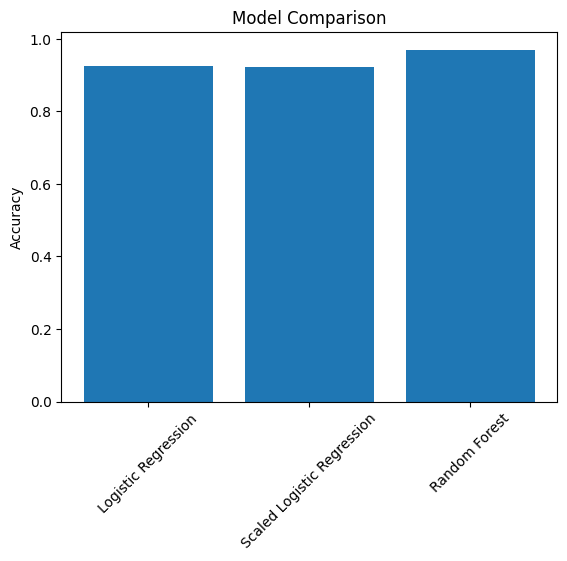

In [ ]:
import matplotlib.pyplot as plt
plt.bar(results["Model"], results["Accuracy"])
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()

FEATURE IMPORTANCE

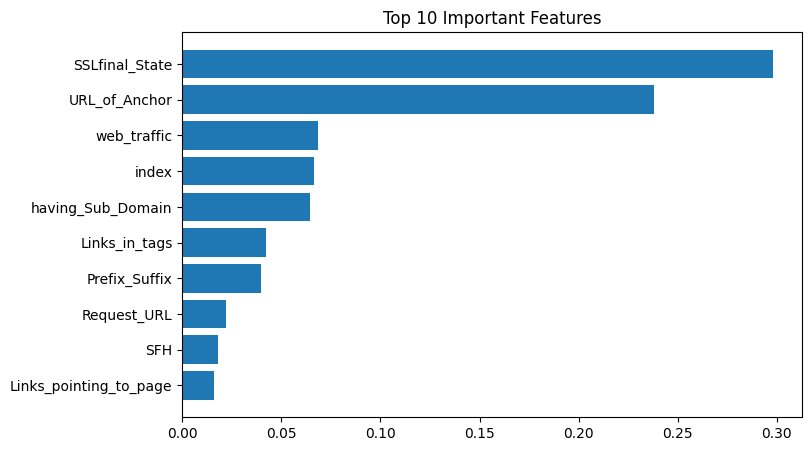

In [ ]:
import numpy as np
importances = model_rf.feature_importances_
indices = np.argsort(importances)[-10:]
plt.figure(figsize=(8,5))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.title("Top 10 Important Features")
plt.show()

ROC CURVE

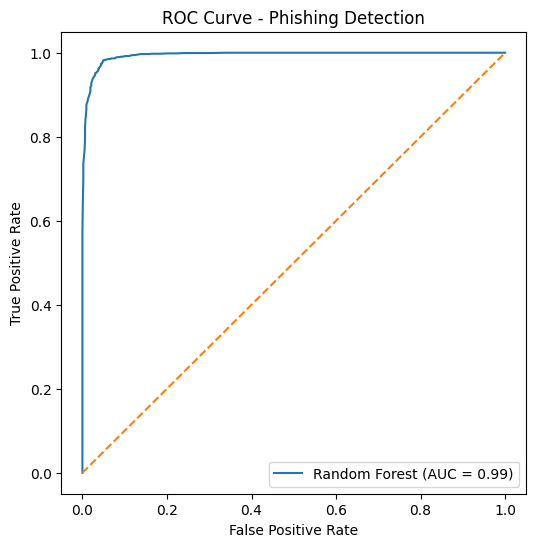

AUC Score: 0.9941639300538432


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
y_probs = model_rf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label="Random Forest (AUC = %0.2f)" % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Phishing Detection")
plt.legend()
plt.show()
print("AUC Score:", roc_auc)